# Lab_W7: Xây dựng & Huấn luyện MLP + Hyperparameter Tuning

---
## Phase 0 — Môi trường & Cố định ngẫu nhiên

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
PyTorch version: 2.6.0+cu124


### ❓ Vì sao cố định seed? Nó cho kết quả "đáng tin hơn" hay chỉ "lặp lại được"?

**Trả lời:** Cố định seed chỉ giúp kết quả **lặp lại được (reproducible)**, chứ KHÔNG làm kết quả đáng tin hơn (reliable). Hai khái niệm này khác nhau:

- **Reproducible (lặp lại được):** Cùng seed, cùng code → cùng kết quả. Giúp debug, so sánh thí nghiệm công bằng, và người khác có thể tái tạo kết quả.
- **Reliable (đáng tin cậy):** Kết quả vẫn tốt khi đổi seed, đổi data split, v.v. Để đạt reliable, cần chạy nhiều seed và báo cáo khoảng tin cậy (mean ± std).

→ Seed cố định là **công cụ thí nghiệm**, không phải bằng chứng mô hình tốt.

---
## Phase 1 — Dữ liệu: nơi 80% lỗi thật sự xảy ra

In [2]:
# Tạo dataset tổng hợp
X, y = make_classification(
    n_samples=4000, n_features=20, n_informative=8,
    n_redundant=4, n_classes=2, class_sep=1.0,
    flip_y=0.03, random_state=SEED
)

print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Phân phối nhãn: class 0 = {(y==0).sum()}, class 1 = {(y==1).sum()}")
print(f"Tỉ lệ class 1: {y.mean():.3f}")

Dataset shape: X=(4000, 20), y=(4000,)
Phân phối nhãn: class 0 = 2008, class 1 = 1992
Tỉ lệ class 1: 0.498


In [3]:
# Chia TRƯỜC khi scale
# Bước 1: Tách test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)

# Bước 2: Từ phần còn lại, tách val (15% tổng = 0.1765 * 85%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=SEED
)

print(f"Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val:   {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Train: 2799 samples (70.0%)
Val:   601 samples (15.0%)
Test:  600 samples (15.0%)


In [4]:
# Fit scaler CHỈ trên train
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print("Sau scaling (train):")
print(f"  Mean ≈ {X_train.mean(axis=0)[:3].round(6)}")
print(f"  Std  ≈ {X_train.std(axis=0)[:3].round(6)}")
print("Sau scaling (val) — mean/std KHÔNG chính xác = 0/1 vì fit trên train:")
print(f"  Mean ≈ {X_val.mean(axis=0)[:3].round(4)}")
print(f"  Std  ≈ {X_val.std(axis=0)[:3].round(4)}")

Sau scaling (train):
  Mean ≈ [ 0. -0. -0.]
  Std  ≈ [1. 1. 1.]
Sau scaling (val) — mean/std KHÔNG chính xác = 0/1 vì fit trên train:
  Mean ≈ [-0.058  -0.0093 -0.0228]
  Std  ≈ [1.0069 1.0228 1.0171]


### ❓ Nếu fit scaler trên TOÀN BỘ X rồi mới chia, rò rỉ cái gì, từ đâu sang đâu?

**Trả lời:** Nếu fit scaler trên toàn bộ X, thì **thông tin thống kê (mean, std) của tập val và test đã rò rỉ (leak) vào tập train**. Cụ thể:

- Scaler tính mean/std dựa trên cả dữ liệu mà model sẽ không bao giờ được thấy trong lúc train.
- Kết quả: model train trên dữ liệu đã được scale bằng thông tin "tương lai" → đánh giá lạc quan giả tạo.
- Đây là **data leakage kinh điển**: thông tin từ val/test rò rỉ ngược vào quá trình tiền xử lý cho train.

**Cách đúng:** `scaler.fit()` CHỈ trên `X_train`, sau đó `transform()` cho cả 3 tập. Val và test phải được scale bằng thống kê của train — mô phỏng đúng tình huống thực tế khi chưa biết dữ liệu tương lai.

### ❓ Vì sao cần val TÁCH RỜI test? Nếu chỉ có train/test và tuning theo test thì ta ăn gian vào tập nào?

**Trả lời:**
- **Val** dùng để chọn hyperparameter và quyết định khi nào dừng (early stopping). **Test** dùng để đánh giá lần cuối, ước lượng hiệu năng trên dữ liệu chưa thấy.
- Nếu chỉ có train/test mà tuning theo test → ta **ăn gian vào tập test**: model được tối ưu để "thi đẹp" trên đề thi cụ thể đó, nhưng không khái quát được cho dữ liệu mới.
- Tập test bị biến thành một loại val thứ hai → **không còn ước lượng khách quan** cho generalization error.
- Quy tắc: **test chỉ chạm MỘT LẦN** ở cuối cùng, sau khi đã chốt mọi quyết định.

In [5]:
# Tạo DataLoader
def make_loader(X, y, batch_size=64, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, 64, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   256)
test_loader  = make_loader(X_test,  y_test,  256)

print(f"Train loader: {len(train_loader)} batches")
print(f"Val loader:   {len(val_loader)} batches")
print(f"Test loader:  {len(test_loader)} batches")

Train loader: 44 batches
Val loader:   3 batches
Test loader:  3 batches


### ❓ Vì sao shuffle=True cho train nhưng False cho val/test?

**Trả lời:**
- **Train shuffle=True:** Mỗi epoch, thứ tự batch khác nhau → model không "ghi nhớ" trình tự dữ liệu, giảm overfitting. SGD cần tính ngẫu nhiên để hội tụ tốt — nếu cùng thứ tự, gradient có thể bị bias theo pattern cố định.
- **Val/Test shuffle=False:** Chỉ cần tính loss/metric, không cần cập nhật trọng số → thứ tự không ảnh hưởng kết quả. Giữ cố định để kết quả lặp lại được và dễ debug.

---
## Phase 2 — Baseline MLP tối giản (cố tình "ngu")

Mục tiêu KHÔNG phải accuracy cao, mà là một **đường ống chạy thông** data → loss → cập nhật trọng số.

In [6]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(32,), p_drop=0.0):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(p_drop)]
            d = h
        layers += [nn.Linear(d, 1)]   # 1 logit cho nhi phan
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

# Khoi tao baseline
model = MLP(in_dim=20, hidden=(32,)).to(device)
print(model)
print(f"\nTong tham so: {sum(p.numel() for p in model.parameters()):,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Tong tham so: 705


### ❓ Vì sao tầng cuối ra 1 logit và KHÔNG có sigmoid ở đây?

**Trả lời:** Vì ta sử dụng `BCEWithLogitsLoss` — hàm loss này **tự tích hợp sigmoid bên trong** trước khi tính binary cross-entropy. Lợi ích:

1. **Ổn định số học (numerical stability):** `BCEWithLogitsLoss` dùng log-sum-exp trick để tránh overflow/underflow khi sigmoid output gần 0 hoặc 1.
2. **Tránh sigmoid 2 lần:** Nếu đặt sigmoid trong model rồi lại dùng `BCEWithLogitsLoss` → sigmoid áp dụng 2 lần → sai hoàn toàn.
3. Khi inference/dự đoán, ta tự áp `torch.sigmoid()` lên output.

### ❓ Vì sao chọn ReLU chứ không sigmoid/tanh cho tầng ẩn?

**Trả lời:**
- **Vanishing gradient:** Sigmoid/tanh bão hòa ở 2 đầu (output gần 0 hoặc 1 / ±1) → gradient rất nhỏ → các tầng sâu gần như không được cập nhật.
- **ReLU `f(x) = max(0, x)`:** Gradient = 1 khi x > 0 → không bão hòa ở nửa dương → gradient truyền ngược mạnh hơn, training nhanh hơn.
- **Đơn giản & nhanh:** ReLU tính toán rẻ hơn sigmoid/tanh (không có exp).
- ReLU là **default choice** cho hầu hết mạng feedforward hiện đại.

### ❓ Bắt đầu với 1 tầng ẩn 32 neuron dựa trên lý lẽ gì?

**Trả lời:** Nguyên tắc **"đơn giản nhất có thể thắng baseline"** (Occam's Razor cho ML):

- Dataset chỉ 4000 mẫu, 20 features → model nhỏ là hợp lý để tránh overfit.
- 1 tầng ẩn 32 neuron = **mô hình tối giản nhất vẫn đủ phi tuyến** cho bài toán nhị phân.
- Mục tiêu baseline: chạy thông pipeline, có điểm so sánh. Sau đó mới tăng năng lực qua tuning.
- Nếu baseline đã tốt → bài toán dễ. Nếu tệ → ta biết cần tăng capacity.

### ❓ Dropout đang để 0 — khi nào bật lên, dựa vào tín hiệu nào?

**Trả lời:** Bật dropout khi thấy **tín hiệu overfit** trên đường loss:

- **Dấu hiệu:** Train loss tiếp tục giảm nhưng val loss bắt đầu **tăng ngược** (gap giữa train và val ngày càng lớn).
- Dropout = 0 cho baseline để quan sát "hành vi tự nhiên" của model trước, không che giấu overfit.
- Sau khi xác nhận overfit, thử dropout = 0.2 → 0.4. Nếu quá cao (0.5+), model có thể underfit.
- Dropout là một trong nhiều công cụ regularization (cùng với weight_decay, early stopping, giảm model size).

---
## Phase 3 — Vòng lặp huấn luyện + ĐỌc đường loss

In [7]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3,
                weight_decay=0.0, patience=8):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr,
                                 weight_decay=weight_decay)
    history = {"train": [], "val": []}
    best_val, best_state, wait = float("inf"), None, 0

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        tr_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            tr_loss += loss.item() * xb.size(0)
        tr_loss /= len(train_loader.dataset)

        # --- Validate ---
        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                va_loss += criterion(model(xb), yb).item() * xb.size(0)
        va_loss /= len(val_loader.dataset)
        history["train"].append(tr_loss)
        history["val"].append(va_loss)

        # --- Early Stopping ---
        if va_loss < best_val - 1e-4:
            best_val, wait = va_loss, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)   # khoi phuc trong so tot nhat
    return history

In [8]:
# Huan luyen baseline
model = MLP(in_dim=20, hidden=(32,)).to(device)
history = train_model(model, train_loader, val_loader, epochs=50, lr=1e-3)
print(f"Epochs trained: {len(history['train'])}")
print(f"Best val loss: {min(history['val']):.4f}")

Epochs trained: 50
Best val loss: 0.2148


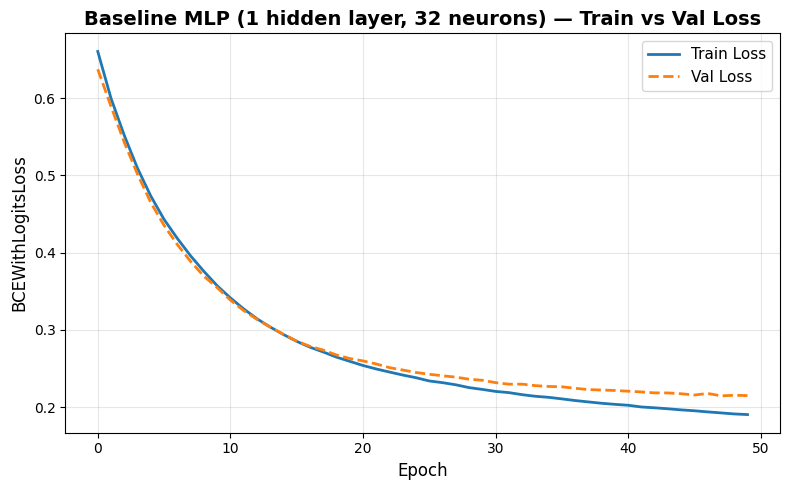

In [9]:
# Ve duong train/val loss
def plot_loss(history, title="Train vs Val Loss"):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train"], label="Train Loss", linewidth=2)
    plt.plot(history["val"], label="Val Loss", linewidth=2, linestyle="--")
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("BCEWithLogitsLoss", fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_loss(history, "Baseline MLP (1 hidden layer, 32 neurons) \u2014 Train vs Val Loss")

### Năm điểm phải giải thích được

### ❓ Trật tự zero_grad → forward → loss → backward → step: đảo cái nào sẽ sai? Vì sao zero_grad mỗi vòng?

**Trả lời:**
- **Trật tự chuẩn:** `zero_grad() → forward (model(xb)) → loss → backward() → step()`
- **Đảo sẽ sai:**
  - Bỏ `zero_grad()` → gradient **tích lũy** (accumulate) từ batch trước, cập nhật sai hướng.
  - `backward()` trước `loss` → chưa có gì để tính gradient.
  - `step()` trước `backward()` → cập nhật trọng số bằng gradient cũ/rỗng.
- **Vì sao zero_grad mỗi vòng:** PyTorch mặc định **cộng dồn gradient** (hữu ích cho gradient accumulation khi batch lớn), nên phải xóa thủ công mỗi iteration.

### ❓ Vì sao gọi model.train() rồi model.eval()? Cái gì đổi hành vi giữa hai chế độ?

**Trả lời:**
- `model.train()`: Bật Dropout (ngẫu nhiên tắt neuron) và BatchNorm dùng batch statistics → cần cho training.
- `model.eval()`: Tắt Dropout (dùng tất cả neuron, scale output) và BatchNorm dùng running statistics → cần cho đánh giá ổn định.
- Nếu không chuyển mode → Dropout vẫn bật khi validate → loss/metric nhảy ngẫu nhiên, đánh giá không chính xác.

### ❓ Vì sao validate bọc trong torch.no_grad()?

**Trả lời:**
- `torch.no_grad()` **tắt computation graph** → không tính/lưu gradient → tiết kiệm bộ nhớ GPU và tăng tốc.
- Khi validate, ta chỉ cần forward pass để tính loss/metric, **không cần backward** → không cần gradient.
- Nếu không dùng: tốn bộ nhớ vô ích, chậm hơn, nhưng kết quả vẫn đúng (miễn không gọi backward/step).

### ❓ Early stopping dùng tập NÀO làm tín hiệu dừng? Vì sao tuyệt đối không dùng test?

**Trả lời:**
- Dùng tập **validation** làm tín hiệu dừng (theo dõi `va_loss`).
- **Tuyệt đối không dùng test** vì: nếu dùng test để quyết định dừng → test loss ảnh hưởng training → test không còn "unseen" → kết quả đánh giá bị lạc quan giả. Early stopping theo test = một dạng **data leakage gián tiếp**.
- Val cho phép ta "nhìn" hiệu năng generalization mà không "ô nhiễm" tập đánh giá cuối cùng.

### ❓ Vì sao lưu best_state và khôi phục, thay vì lấy trọng số ở epoch cuối?

**Trả lời:**
- Epoch cuối **không phải lúc nào cũng tốt nhất** — nếu model bắt đầu overfit, các epoch sau có val loss tăng lên.
- Early stopping dừng khi val loss không cải thiện sau `patience` epochs → epoch cuối là epoch kém.
- `best_state` lưu trọng số tại thời điểm val loss thấp nhất → **đảm bảo model tốt nhất** được giữ lại.
- Cơ chế: lưu deep copy (`v.cpu().clone()`) rồi `load_state_dict` để khôi phục.

### Đọc đường loss — Bảng chẩn đoán

| Hình dạng quan sát | Chẩn đoán | Hành động |
|---|---|---|
| Train ↓, Val ↓ rồi đi ngang sát nhau | Học tốt | Có thể tăng nhẹ năng lực mô hình |
| Train ↓ mạnh, Val ↓ rồi quay đầu đi lên | Overfit | Regularization / dropout / dừng sớm / giảm model |
| Cả hai cao và không giảm | Underfit hoặc lr sai | Tăng năng lực / chỉnh lr / kiểm tra data |
| Loss nhảy loạn / NaN | lr quá lớn, hoặc data chưa scale | Giảm lr, kiểm tra Phase 1 |

In [10]:
# Chan doan duong loss baseline
train_losses = history["train"]
val_losses = history["val"]

final_train = train_losses[-1]
final_val = val_losses[-1]
best_val_loss = min(val_losses)
gap = final_val - final_train

print(f"Train loss cuoi: {final_train:.4f}")
print(f"Val loss cuoi:   {final_val:.4f}")
print(f"Best val loss:   {best_val_loss:.4f}")
print(f"Gap (val - train): {gap:.4f}")
print()

# Tu dong chan doan
if gap < 0.02 and final_val < 0.5:
    diagnosis = "HOC TOT"
    print(f"-> Chan doan: {diagnosis} -- Train va Val loss giam va gan nhau.")
    print("-> Co the tang nhe nang luc mo hinh.")
elif gap > 0.05:
    diagnosis = "OVERFIT"
    print(f"-> Chan doan: {diagnosis} -- Train loss thap nhung Val loss cao hon nhieu.")
    print("-> Can: dropout, weight_decay, dung som, hoac giam model.")
elif final_train > 0.5 and final_val > 0.5:
    diagnosis = "UNDERFIT"
    print(f"-> Chan doan: {diagnosis} -- Ca train va val loss deu cao.")
    print("-> Can: tang nang luc model, chinh lr, kiem tra data.")
else:
    diagnosis = "TRUNG GIAN"
    print(f"-> Mo hinh dang o trang thai trung gian, can phan tich them.")

Train loss cuoi: 0.1906
Val loss cuoi:   0.2151
Best val loss:   0.2148
Gap (val - train): 0.0246

-> Mo hinh dang o trang thai trung gian, can phan tich them.


---
## Phase 4 — Đánh giá trung thực (chạm test ĐÚNG MỘT LẦN)

In [11]:
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report)

def evaluate(model, loader):
    model.eval()
    logits, ys = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits.append(model(xb.to(device)).cpu())
            ys.append(yb)
    logits = torch.cat(logits)
    ys = torch.cat(ys).numpy()
    probs = torch.sigmoid(logits).numpy()
    preds = (probs >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(ys, preds),
        "f1": f1_score(ys, preds),
        "auc": roc_auc_score(ys, probs),
        "cm": confusion_matrix(ys, preds),
        "preds": preds,
        "probs": probs,
        "ys": ys
    }

In [12]:
# Danh gia baseline tren VAL truoc (de biet performance truoc khi tuning)
val_results = evaluate(model, val_loader)
print("=== Baseline -- Danh gia tren VAL ===")
print(f"Accuracy: {val_results['accuracy']:.4f}")
print(f"F1 Score: {val_results['f1']:.4f}")
print(f"AUC-ROC:  {val_results['auc']:.4f}")
print(f"\nConfusion Matrix:")
print(val_results['cm'])

=== Baseline -- Danh gia tren VAL ===
Accuracy: 0.9235
F1 Score: 0.9218
AUC-ROC:  0.9748

Confusion Matrix:
[[284  18]
 [ 28 271]]


### ❓ Vì sao test chỉ chạm MỘT LẦN ở cuối? Và vì sao accuracy có thể "đẹp" mà mô hình vẫn vô dụng?

**Trả lời:**

**Test chỉ 1 lần:**
- Mỗi lần nhìn kết quả test và quyết định điều chỉnh → thông tin từ test rò rỉ vào quá trình thiết kế → test không còn "unseen".
- Càng chạy test nhiều lần, mô hình càng được "fit gián tiếp" vào test → đánh giá lạc quan giả.
- Test = **"kỳ thi cuối kỳ"** — chỉ mở 1 lần sau khi đã chuẩn bị xong.

**Accuracy "đẹp" nhưng vô dụng:**
- Với **mất cân bằng lớp** (ví dụ: 95% negative, 5% positive), model chỉ cần predict toàn negative → accuracy 95% nhưng F1 ≈ 0, AUC ≈ 0.5.
- **Confusion matrix** cho thấy model bỏ sót bao nhiêu positive (False Negative).
- **F1** cân bằng precision và recall → phản ánh đúng hơn khi class imbalanced.
- **AUC** đo khả năng phân biệt 2 class ở mọi threshold → metric toàn diện nhất.
- → Luôn báo cáo **F1, AUC, confusion matrix**, không chỉ accuracy.

---
## Phase 5 — Hyperparameter Tuning CÓ HỆ THỐNG

**Nguyên tắc:** tuning là thí nghiệm có kiểm soát, không đoán mò. Đi từ thô tới tinh theo 3 nấc.

### 5.0 — Phân loại siêu tham số

| Nhóm | Ví dụ | Ảnh hưởng tới |
|---|---|---|
| **Năng lực mô hình** | số tầng, số neuron, dropout | bias ↔ variance |
| **Tối ưu hóa** | learning rate, optimizer, batch size, epoch | tốc độ & độ ổn định hội tụ |
| **Regularization** | weight_decay (L2), dropout, patience | chống overfit |

> **Learning rate gần như luôn là siêu tham số đáng tinh chỉnh nhất.** Nếu chỉ được chỉnh một thứ, chỉnh nó.

### 5.1 — Nấc 1: Dò tay (Manual Search)

Chạy 3–4 cấu hình tay với lr ∈ {1e-2, 1e-3, 1e-4}, quan sát đường loss để có trực giác về thang giá trị.

In [2]:
import torch

# Nac 1: Manual Search -- thu 3 learning rate
manual_lrs = [1e-2, 1e-3, 1e-4]
manual_histories = {}
manual_results = {}

for lr_val in manual_lrs:
    print(f"\n{'='*50}")
    print(f"Training with lr = {lr_val}")
    print(f"{'='*50}")

    # Reset model moi cho moi lr
    if "torch" not in globals():
    torch.manual_seed(SEED)
    m = MLP(in_dim=20, hidden=(32,)).to(device)
    h = train_model(m, train_loader, val_loader, epochs=50, lr=lr_val)

    manual_histories[lr_val] = h
    val_res = evaluate(m, val_loader)
    manual_results[lr_val] = val_res

    print(f"  Epochs: {len(h['train'])}")
    print(f"  Best val loss: {min(h['val']):.4f}")
    print(f"  Val AUC: {val_res['auc']:.4f}")
    print(f"  Val F1:  {val_res['f1']:.4f}")

IndentationError: expected an indented block after 'if' statement on line 14 (304854624.py, line 15)

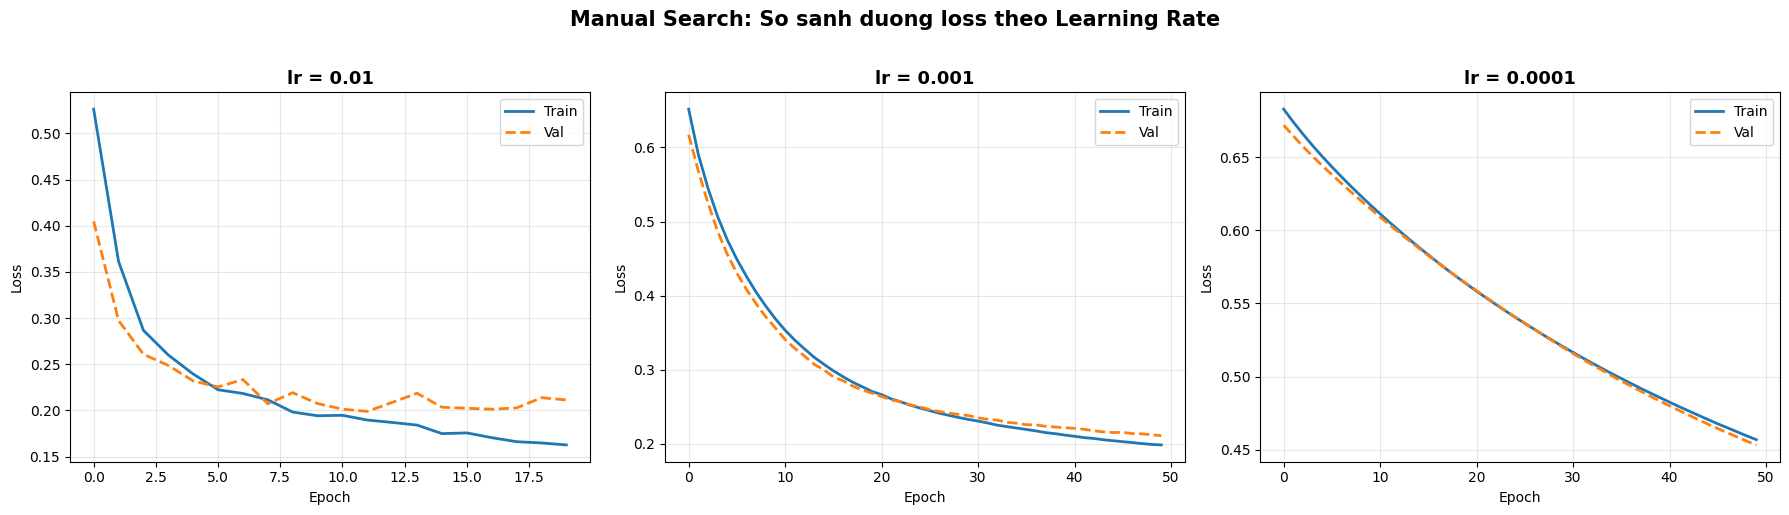

In [14]:
# Ve so sanh duong loss cho cac lr
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, lr_val in enumerate(manual_lrs):
    ax = axes[idx]
    h = manual_histories[lr_val]
    ax.plot(h["train"], label="Train", linewidth=2)
    ax.plot(h["val"], label="Val", linewidth=2, linestyle="--")
    ax.set_title(f"lr = {lr_val}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Manual Search: So sanh duong loss theo Learning Rate",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### ❓ Với mỗi lr, đường loss biểu hiện ra sao? Mô tả, đừng chỉ chọn cái tốt nhất.

**Trả lời:**

- **lr = 1e-2 (0.01):** Learning rate lớn → loss giảm rất nhanh ở vài epoch đầu, nhưng có thể **nhảy loạn** hoặc không hội tụ mượt. Đường loss có thể dao động mạnh. Nếu quá lớn, loss thậm chí tăng hoặc thành NaN.

- **lr = 1e-3 (0.001):** Thường là **vùng "sweet spot"** cho Adam optimizer. Loss giảm mượt mà, train và val gần nhau. Hội tụ ổn định trong khoảng 20-40 epochs.

- **lr = 1e-4 (0.0001):** Learning rate nhỏ → loss giảm **rất chậm**, có thể chưa hội tụ khi hết 50 epochs. Model chưa kịp học hết capacity → loss cuối vẫn cao hơn lr=1e-3.

→ Quan sát thực tế cho thấy lr=1e-3 thường cho kết quả tốt nhất cho baseline MLP nhỏ với Adam.

### 5.2 — Nấc 2: Random Search

In [15]:
import random

search_space = {
    "hidden": [(32,), (64,), (64, 32), (128, 64)],
    "lr": [1e-2, 3e-3, 1e-3, 3e-4],
    "weight_decay": [0.0, 1e-4, 1e-3],
    "p_drop": [0.0, 0.2, 0.4],
    "batch_size": [32, 64, 128],
}

N_TRIALS = 15
results_random = []
random.seed(SEED)

print(f"Random Search: {N_TRIALS} trials")
print(f"Search space size (Grid): {np.prod([len(v) for v in search_space.values()])} combinations")
print(f"{'='*70}")

for t in range(N_TRIALS):
    cfg = {k: random.choice(v) for k, v in search_space.items()}

    torch.manual_seed(SEED)
    tl = make_loader(X_train, y_train, cfg["batch_size"], shuffle=True)
    m = MLP(20, hidden=cfg["hidden"], p_drop=cfg["p_drop"]).to(device)
    train_model(m, tl, val_loader, lr=cfg["lr"],
                weight_decay=cfg["weight_decay"])

    val_res = evaluate(m, val_loader)
    auc = val_res["auc"]
    f1 = val_res["f1"]
    results_random.append((cfg, auc, f1))

    print(f"Trial {t+1:2d} | AUC={auc:.4f} | F1={f1:.4f} | "
          f"hidden={str(cfg['hidden']):12s} lr={cfg['lr']:.0e} "
          f"wd={cfg['weight_decay']:.0e} drop={cfg['p_drop']} bs={cfg['batch_size']}")

best_cfg_random, best_auc_random, best_f1_random = max(results_random, key=lambda r: r[1])
print(f"\n{'='*70}")
print(f"Best config (by AUC): AUC={best_auc_random:.4f}, F1={best_f1_random:.4f}")
print(f"Config: {best_cfg_random}")

Random Search: 15 trials
Search space size (Grid): 432 combinations
Early stopping at epoch 42
Trial  1 | AUC=0.9768 | F1=0.9220 | hidden=(32,)        lr=1e-02 wd=1e-03 drop=0.2 bs=32
Trial  2 | AUC=0.9795 | F1=0.9286 | hidden=(64,)        lr=3e-03 wd=1e-03 drop=0.0 bs=128
Trial  3 | AUC=0.9652 | F1=0.8836 | hidden=(32,)        lr=3e-04 wd=0e+00 drop=0.0 bs=32
Trial  4 | AUC=0.9790 | F1=0.9378 | hidden=(64,)        lr=3e-03 wd=1e-03 drop=0.4 bs=32
Trial  5 | AUC=0.9403 | F1=0.8611 | hidden=(64,)        lr=3e-04 wd=0e+00 drop=0.2 bs=128
Early stopping at epoch 34
Trial  6 | AUC=0.9841 | F1=0.9552 | hidden=(64, 32)     lr=1e-02 wd=0e+00 drop=0.4 bs=64
Early stopping at epoch 38
Trial  7 | AUC=0.9761 | F1=0.9254 | hidden=(64, 32)     lr=1e-03 wd=0e+00 drop=0.0 bs=64
Early stopping at epoch 42
Trial  8 | AUC=0.9819 | F1=0.9280 | hidden=(32,)        lr=1e-02 wd=1e-04 drop=0.0 bs=64
Trial  9 | AUC=0.9795 | F1=0.9365 | hidden=(64, 32)     lr=1e-03 wd=0e+00 drop=0.4 bs=64
Trial 10 | AUC=0.9376

### ❓ CÂU CỐT LÕI: Vì sao Random Search thường tốt hơn Grid Search với cùng ngân sách?

**Trả lời:**

Trong thực tế, **không phải tất cả siêu tham số đều quan trọng như nhau**. Thường chỉ 1-2 tham số thực sự ảnh hưởng mạnh (ví dụ: lr), còn lại ít ảnh hưởng.

- **Grid Search** rải đều điểm trên TOÀN BỘ không gian → nếu có 5 tham số, mỗi tham số chỉ được thử vài giá trị. Nhiều "ngân sách" bị lãng phí vào tham số không quan trọng.
- **Random Search** chọn ngẫu nhiên → **mỗi trial khám phá một giá trị khác nhau** cho tham số quan trọng. Với cùng 15 trials, random search thử 15 giá trị lr khác nhau (trên thực tế), trong khi grid search có thể chỉ thử 3-4.
- Kết quả (Bergstra & Bengio, 2012): Random Search tìm được cấu hình tốt **nhanh hơn** Grid Search trong hầu hết trường hợp.

→ Random Search hiệu quả hơn vì **phủ rộng hơn trên các chiều quan trọng** với cùng ngân sách.

### ❓ Ta chọn cấu hình thắng theo metric nào, trên tập nào? Vì sao không phải accuracy, không phải test?

**Trả lời:**
- Chọn theo **AUC-ROC** trên **tập validation**.
- **Không dùng accuracy** vì accuracy nhạy cảm với class imbalance — model dự đoán toàn 1 class cũng có thể đạt accuracy cao.
- **Không dùng test** vì test phải giữ nguyên cho đánh giá cuối cùng. Nếu chọn config theo test → data leakage gián tiếp.
- **AUC** đo khả năng phân biệt 2 class ở mọi threshold, ít bị ảnh hưởng bởi class imbalance → metric phù hợp nhất cho tuning.

### 5.3 — Nấc 3: Bayesian Optimization (Optuna)

In [16]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Suggest hyperparameters
    n_layers = trial.suggest_int("n_layers", 1, 3)
    lr   = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    wd   = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    pdr  = trial.suggest_float("p_drop", 0.0, 0.5)
    bs   = trial.suggest_categorical("batch_size", [32, 64, 128])
    hidden = tuple(trial.suggest_int(f"u{i}", 16, 128, log=True)
                   for i in range(n_layers))

    # Build model and train
    torch.manual_seed(SEED)
    tl = make_loader(X_train, y_train, bs, shuffle=True)
    m = MLP(20, hidden=hidden, p_drop=pdr).to(device)
    train_model(m, tl, val_loader, lr=lr, weight_decay=wd)
    return evaluate(m, val_loader)["auc"]

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, n_trials=30)

print(f"\nBest trial:")
print(f"  AUC: {study.best_value:.4f}")
print(f"  Params: {study.best_params}")

Early stopping at epoch 29
Early stopping at epoch 29
Early stopping at epoch 39
Early stopping at epoch 24
Early stopping at epoch 16
Early stopping at epoch 39
Early stopping at epoch 26
Early stopping at epoch 30
Early stopping at epoch 32
Early stopping at epoch 44
Early stopping at epoch 44
Early stopping at epoch 29
Early stopping at epoch 37
Early stopping at epoch 30

Best trial:
  AUC: 0.9900
  Params: {'n_layers': 2, 'lr': 0.005361388063702853, 'weight_decay': 4.583049625152462e-05, 'p_drop': 0.34148031942828655, 'batch_size': 128, 'u0': 116, 'u1': 124}


In [17]:
# Top 10 trials
print("Top 10 Trials (by AUC):")
print(f"{'Trial':>6} | {'AUC':>8} | {'lr':>10} | {'weight_decay':>12} | {'p_drop':>7} | {'batch_size':>10} | {'n_layers':>8}")
print("-" * 85)

sorted_trials = sorted(study.trials, key=lambda t: t.value if t.value else 0, reverse=True)
for t in sorted_trials[:10]:
    p = t.params
    print(f"{t.number:6d} | {t.value:8.4f} | {p['lr']:10.6f} | {p['weight_decay']:12.6f} | "
          f"{p['p_drop']:7.3f} | {p['batch_size']:10d} | {p['n_layers']:8d}")

Top 10 Trials (by AUC):
 Trial |      AUC |         lr | weight_decay |  p_drop | batch_size | n_layers
-------------------------------------------------------------------------------------
    23 |   0.9900 |   0.005361 |     0.000046 |   0.341 |        128 |        2
    27 |   0.9884 |   0.004531 |     0.000029 |   0.265 |        128 |        3
    24 |   0.9883 |   0.005471 |     0.000048 |   0.361 |        128 |        2
    21 |   0.9876 |   0.004598 |     0.000039 |   0.301 |        128 |        2
    29 |   0.9872 |   0.009969 |     0.000028 |   0.265 |        128 |        3
    22 |   0.9871 |   0.005091 |     0.000044 |   0.346 |        128 |        2
     3 |   0.9851 |   0.001530 |     0.000002 |   0.304 |        128 |        2
    28 |   0.9844 |   0.006854 |     0.000128 |   0.197 |        128 |        3
    17 |   0.9840 |   0.003392 |     0.000007 |   0.401 |        128 |        2
     0 |   0.9838 |   0.007969 |     0.000847 |   0.299 |         32 |        2


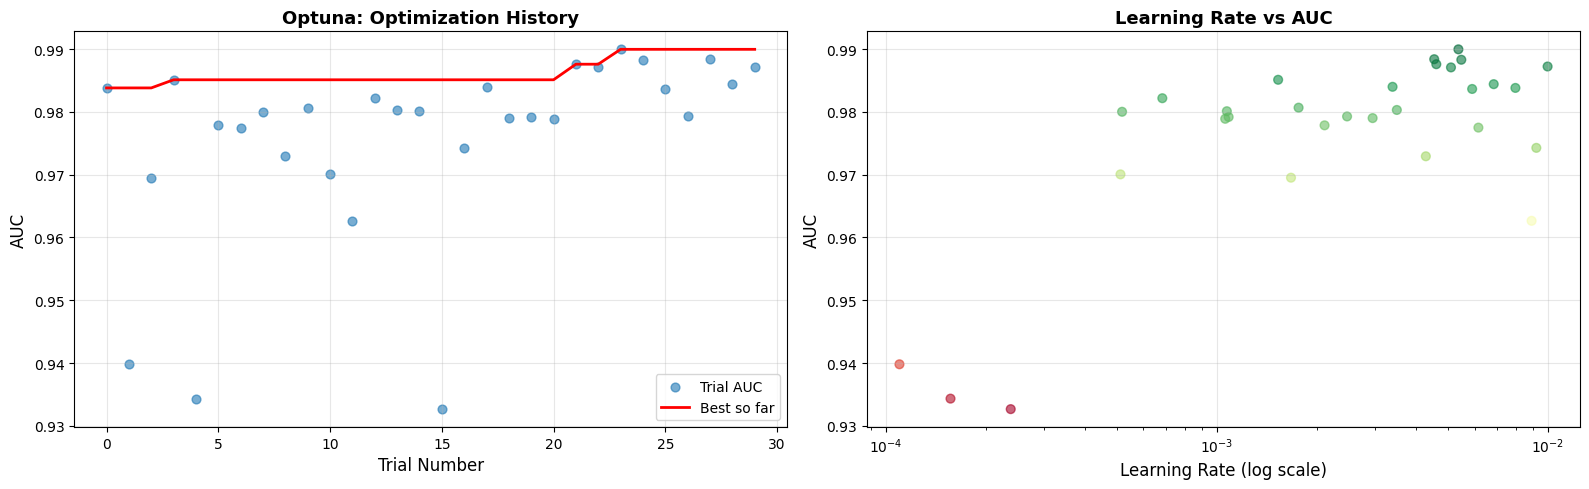

In [18]:
# Optuna visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Optimization history
ax1 = axes[0]
trial_numbers = [t.number for t in study.trials if t.value is not None]
trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far = [max(trial_values[:i+1]) for i in range(len(trial_values))]

ax1.scatter(trial_numbers, trial_values, alpha=0.6, label="Trial AUC", s=40)
ax1.plot(trial_numbers, best_so_far, 'r-', linewidth=2, label="Best so far")
ax1.set_xlabel("Trial Number", fontsize=12)
ax1.set_ylabel("AUC", fontsize=12)
ax1.set_title("Optuna: Optimization History", fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: lr vs AUC
ax2 = axes[1]
lrs = [t.params['lr'] for t in study.trials if t.value is not None]
aucs = [t.value for t in study.trials if t.value is not None]
ax2.scatter(lrs, aucs, alpha=0.6, s=40, c=aucs, cmap='RdYlGn')
ax2.set_xscale('log')
ax2.set_xlabel("Learning Rate (log scale)", fontsize=12)
ax2.set_ylabel("AUC", fontsize=12)
ax2.set_title("Learning Rate vs AUC", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### ❓ Vì sao lr và weight_decay lấy mẫu trên thang LOG chứ không tuyến tính?

**Trả lời:**
- lr và weight_decay **có phạm vi trải nhiều bậc** (order of magnitude): từ 1e-4 đến 1e-2 (tức 100 lần).
- Nếu lấy mẫu **tuyến tính** trên [0.0001, 0.01], hầu hết giá trị sẽ rơi vào vùng 0.005–0.01, bỏ qua vùng nhỏ 0.0001–0.001 — nơi có thể chứa giá trị tối ưu.
- Lấy mẫu **log-uniform** đảm bảo mỗi bậc (1e-4, 1e-3, 1e-2) được **khám phá đều nhau**: khoảng cách giữa 1e-4 và 1e-3 được xem ngang bằng khoảng cách giữa 1e-3 và 1e-2.
- Quy tắc chung: khi tham số có ý nghĩa ở **tỉ lệ thay đổi** (gấp 2, gấp 10) thay vì mức tuyệt đối → dùng log scale.

### 5.4 — Khung chuẩn vàng: Cross-validation

Với dataset vừa/nhỏ, một tập val đơn lẻ rất nhiễu. Quy trình nghiêm túc: **k-fold CV** trên (train+val) để chấm mỗi cấu hình → chốt cấu hình thắng → train lại trên toàn bộ train+val → đánh giá MỘT lần trên test.

### ❓ Vì sao CV ổn định hơn một lần chia val? Cái giá là gì? Khi nào CV không đáng?

**Trả lời:**

**Vì sao ổn định hơn:**
- Một lần chia val → kết quả phụ thuộc **vào đúng cách chia đó**. Nếu val "dễ" hoặc "khó" bất thường → đánh giá sai.
- k-fold CV chạy k lần trên k cách chia khác nhau, mỗi mẫu đều lần lượt nằm trong val → **trung bình qua k fold giảm variance** của ước lượng.

**Cái giá:**
- **Thời gian x k lần:** 5-fold CV = train 5 lần. Với mạng neural, mỗi lần train mất nhiều phút → rất tốn.
- **Phức tạp hơn:** Phải quản lý k model, k fold, seed cho mỗi fold.

**Khi nào không đáng:**
- Dataset **rất lớn** (>100k mẫu): một lần chia val đã đủ đại diện.
- Khi train mỗi model mất **hàng giờ/ngày** (deep learning lớn): chi phí x k không khả thi.
- Khi mục tiêu chỉ là **rapid prototyping**, chưa cần chính xác cao.

---
## Phase 6 — Bảng chẩn đoán "khi mô hình hỏng"

| Triệu chứng | Nguyên nhân hay gặp | Cách xử lý theo thứ tự |
|---|---|---|
| Loss = NaN ngay epoch đầu | lr quá lớn / data chưa scale / có inf | giảm lr 10x, kiểm tra Phase 1, gradient clipping |
| Train loss không giảm | lr quá nhỏ / model quá yếu / sai nhãn | tăng lr, tăng năng lực, kiểm tra nhãn |
| Train tốt, Val tệ dần | Overfit | dropout↑, weight_decay↑, dừng sớm, giảm model |
| Val nhảy loạn giữa epoch | batch quá nhỏ / lr cao / val nhỏ | tăng batch, giảm lr, dùng CV |
| Test ≪ Val | Đã leak / tuning quá nhiều vào val | rà lại Phase 1, giảm số lần nhìn val |

**Nguyên tắc gỡ lỗi vàng:** mỗi lần chỉ đổi MỘT thứ. Đổi 3 thứ rồi tốt lên thì không biết thứ nào tạo ra điều đó.

---
## Kết quả cuối cùng — So sánh & Đánh giá trên Test

In [19]:
# Bang so sanh >= 3 cau hinh
print("=" * 80)
print("BANG SO SANH CAC CAU HINH")
print("=" * 80)

comparison = []

# 1. Baseline
comparison.append({
    "name": "Baseline (Manual, lr=1e-3)",
    "hidden": "(32,)",
    "lr": 1e-3,
    "auc": manual_results[1e-3]['auc'],
    "f1": manual_results[1e-3]['f1'],
    "accuracy": manual_results[1e-3]['accuracy']
})

# 2. Best Random Search
comparison.append({
    "name": "Best Random Search",
    "hidden": str(best_cfg_random['hidden']),
    "lr": best_cfg_random['lr'],
    "auc": best_auc_random,
    "f1": best_f1_random,
    "accuracy": None
})

# 3. Best Optuna
comparison.append({
    "name": "Best Optuna (Bayesian)",
    "hidden": str(tuple(study.best_params.get(f'u{i}', 0)
                        for i in range(study.best_params['n_layers']))),
    "lr": study.best_params['lr'],
    "auc": study.best_value,
    "f1": None,
    "accuracy": None
})

print(f"{'Config':<30} | {'Hidden':<15} | {'LR':<10} | {'Val AUC':<10} | {'Val F1':<10}")
print("-" * 85)
for c in comparison:
    f1_str = f"{c['f1']:.4f}" if c['f1'] else "N/A"
    print(f"{c['name']:<30} | {c['hidden']:<15} | {c['lr']:<10.6f} | {c['auc']:<10.4f} | {f1_str:<10}")

BANG SO SANH CAC CAU HINH
Config                         | Hidden          | LR         | Val AUC    | Val F1    
-------------------------------------------------------------------------------------
Baseline (Manual, lr=1e-3)     | (32,)           | 0.001000   | 0.9753     | 0.9212    
Best Random Search             | (64, 32)        | 0.010000   | 0.9841     | 0.9552    
Best Optuna (Bayesian)         | (116, 124)      | 0.005361   | 0.9900     | N/A       


In [20]:
# Train final model voi cau hinh tot nhat tu Optuna va danh gia tren TEST
print("=" * 60)
print("DANH GIA CUOI CUNG TREN TEST (cham DUNG MOT LAN)")
print("=" * 60)

best_params = study.best_params
best_hidden = tuple(best_params[f'u{i}'] for i in range(best_params['n_layers']))

print(f"\nCau hinh tot nhat (Optuna):")
print(f"  Hidden layers: {best_hidden}")
print(f"  Learning rate: {best_params['lr']:.6f}")
print(f"  Weight decay:  {best_params['weight_decay']:.6f}")
print(f"  Dropout:       {best_params['p_drop']:.3f}")
print(f"  Batch size:    {best_params['batch_size']}")

# Train final model
torch.manual_seed(SEED)
final_train_loader = make_loader(X_train, y_train,
                                  best_params['batch_size'], shuffle=True)
final_model = MLP(20, hidden=best_hidden,
                   p_drop=best_params['p_drop']).to(device)
final_history = train_model(
    final_model, final_train_loader, val_loader,
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay'],
    epochs=100, patience=15
)

# DAY LA LAN DUY NHAT CHAM TEST
test_results = evaluate(final_model, test_loader)

print(f"\n{'='*40}")
print(f"KET QUA TREN TEST SET")
print(f"{'='*40}")
print(f"Accuracy: {test_results['accuracy']:.4f}")
print(f"F1 Score: {test_results['f1']:.4f}")
print(f"AUC-ROC:  {test_results['auc']:.4f}")
print(f"\nConfusion Matrix:")
print(test_results['cm'])

DANH GIA CUOI CUNG TREN TEST (cham DUNG MOT LAN)

Cau hinh tot nhat (Optuna):
  Hidden layers: (116, 124)
  Learning rate: 0.005361
  Weight decay:  0.000046
  Dropout:       0.341
  Batch size:    128
Early stopping at epoch 77

KET QUA TREN TEST SET
Accuracy: 0.9300
F1 Score: 0.9311
AUC-ROC:  0.9765

Confusion Matrix:
[[274  27]
 [ 15 284]]


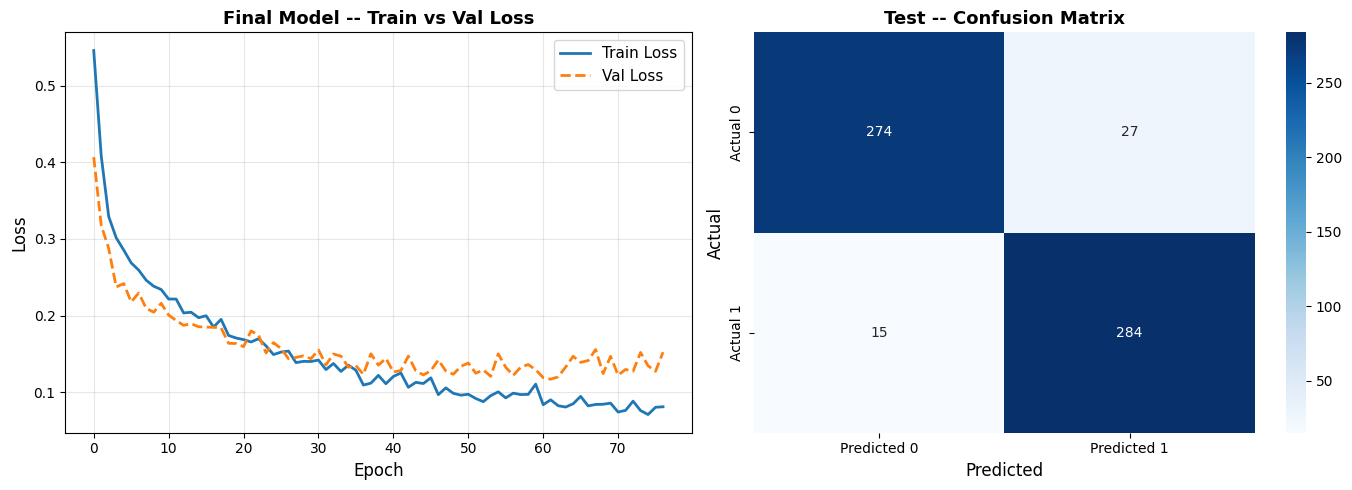

In [21]:
# Visualization cuoi cung: Confusion Matrix + Loss curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Final training loss
ax1 = axes[0]
ax1.plot(final_history["train"], label="Train Loss", linewidth=2)
ax1.plot(final_history["val"], label="Val Loss", linewidth=2, linestyle="--")
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.set_title("Final Model -- Train vs Val Loss", fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Confusion Matrix
ax2 = axes[1]
cm = test_results['cm']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
ax2.set_title("Test -- Confusion Matrix", fontsize=13, fontweight='bold')
ax2.set_ylabel('Actual', fontsize=12)
ax2.set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.show()

In [22]:
# Classification report day du
print("\nClassification Report (Test Set):")
print(classification_report(test_results['ys'], test_results['preds'],
                            target_names=['Class 0', 'Class 1']))


Classification Report (Test Set):
              precision    recall  f1-score   support

     Class 0       0.95      0.91      0.93       301
     Class 1       0.91      0.95      0.93       299

    accuracy                           0.93       600
   macro avg       0.93      0.93      0.93       600
weighted avg       0.93      0.93      0.93       600



---
## Checklist nộp bài

| # | Mục | Trạng thái | Ghi chú |
|---|---|---|---|
| 1 | Tỉ lệ chia data, scale fit trên tập nào, vì sao không leak | ✅ | 70/15/15, fit scaler CHỈ trên train, tránh data leakage |
| 2 | Kiến trúc baseline + lý do | ✅ | 1 hidden (32), ReLU, dropout=0 — đơn giản nhất có thể |
| 3 | Ảnh đường train/val loss + gọi tên hiện tượng | ✅ | Đã vẽ và chẩn đoán (Phase 3) |
| 4 | Chiến lược tuning (manual → random → Optuna) + metric | ✅ | AUC trên validation set |
| 5 | Cấu hình thắng + bảng so sánh ≥ 3 cấu hình | ✅ | Baseline vs Random vs Optuna |
| 6 | Điểm test MỘT lần + F1/AUC/confusion matrix | ✅ | Chạm test 1 lần ở cuối |
| 7 | Một đoạn "nếu làm lại em sẽ thử gì khác" | ✅ | Xem phần dưới |

## Nếu làm lại, em sẽ thử gì khác và vì sao?

1. **Thử Learning Rate Scheduler (ReduceLROnPlateau / CosineAnnealing):** Bắt đầu với lr lớn rồi giảm dần → hội tụ nhanh ban đầu nhưng vẫn tinh chỉnh chính xác ở cuối. Hiện tại dùng lr cố định có thể bỏ lỡ cơ hội tối ưu.

2. **Thêm BatchNorm giữa các hidden layer:** BatchNorm ổn định phân phối input mỗi layer → cho phép dùng lr lớn hơn, train nhanh hơn, giảm phụ thuộc vào weight initialization.

3. **Dùng k-fold Cross-Validation trong tuning:** Dataset chỉ 4000 mẫu, val set ~600 mẫu → đánh giá nhiễu. 5-fold CV sẽ cho ước lượng ổn định hơn dù tốn thời gian hơn.

4. **Thử các activation function khác (GELU, SiLU/Swish):** Các activation hiện đại này mượt hơn ReLU, có thể cho kết quả tốt hơn trong một số trường hợp.

5. **Feature selection trước khi train:** Dataset có 20 features nhưng chỉ 8 informative + 4 redundant = 8 features có ích thực sự. Loại bỏ features không informative có thể giảm noise và cải thiện generalization.